In [11]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


import scanpy as sc

import os

import scvi

import seaborn as sns


def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols

# Some canonical markers for PBMC cell types that I found
canonical_markers = ["IL32", "LTB", "CD3D",
    "IL7R", "LDHB", "FCGR3A", 
    "CD68", "MS4A1", "GNLY", 
    "CD3E", "CD14", "CD14", 
    "FCGR3A", "LYZ", "PPBP", 
    "CD8A", "PPBP", "CST3", 
    "NKG7", "MS4A7", "MS4A1", 
    "CD8A", "CD4", "NCAM1"]

    

In [12]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

h5_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2-outs-raw_feature_bc_matrix-matrix.h5ad')

barcodes_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.barcodes.tsv')

features_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.features.tsv')

h5 = sc.read_h5ad(h5_file)

features_pd = pd.read_csv(features_file, header=None, sep='\t')

barcodes_pd = pd.read_csv(barcodes_file, header=None, sep='\t')

## It's feature -by- barcode matrix, need to transpose
h5.var = barcodes_pd
h5.obs = features_pd 
h5.obs.columns = ['feature_id', 'name', 'feature_type', 'chrom', 'start', 'end']
h5.var.columns = ['barcodes']


## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_downstream_dir = os.path.join(entropy_dir, 'DownstreamReanalysis')
entropy_peak_file = os.path.join(entropy_downstream_dir, 'entropy_peakvi.h5ad')
peak_file = os.path.join(entropy_downstream_dir, 'peakvi.h5ad')

entropy_peak = sc.read_h5ad(entropy_peak_file)
peak = sc.read_h5ad(peak_file)

# Rename peakvi clustering columns
entropy_peak.obs['clusters_peakvi_entropy'] = entropy_peak.obs['clusters_peakvi']
peak.obs['clusters_peakvi_standard'] = peak.obs['clusters_peakvi']

# Load entropy score and add to entropy_peak obs
entropy_score_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_score_pd = pd.read_csv(entropy_score_file, sep=',', index_col=0)
entropy_peak.obs = entropy_peak.obs.merge(entropy_score_pd[['Entropy', 'Entropy_open_region']], left_on='barcodes', right_index=True, how='left')



# atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')



## load peakvi models for DARS analysis 
standard_peak_model_dir = os.path.join(entropy_downstream_dir, 'standard_peak_peakvi_model')
entropy_peak_model_dir =os.path.join(entropy_downstream_dir, 'entropy_peak_peakvi_model')
standard_peak_model =scvi.model.PEAKVI.load(standard_peak_model_dir, adata=peak)
entropy_peak_model =scvi.model.PEAKVI.load(entropy_peak_model_dir, adata=entropy_peak)


# Summary statistics about Fraction of Reads in Peaks (FRIP)
standard_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_peaks.csv')
entropy_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_entropypeaks.csv')


standard_peak_frip = pd.read_csv(standard_peak_frip_file, index_col=None, sep='\t')
entropy_peak_frip = pd.read_csv(entropy_peak_frip_file, index_col=None, sep='\t')
standard_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip['atac_bc'] = entropy_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip['atac_bc'] = standard_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip.set_index('atac_bc', inplace=True)
entropy_peak_frip.set_index('atac_bc', inplace=True)

INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/DownstreamReanalysis/standard_peak_peakvi_mode
         l/model.pt already downloaded                                                                             


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
entropy_peak, peak, h5, features_pd.shape, barcodes_pd.shape, bc_map_pd.shape

(AnnData object with n_obs × n_vars = 2125 × 36729
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi', 'clusters_peakvi_entropy', 'Entropy', 'Entropy_open_region'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 2125 × 31116
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi', 'clusters_peakvi_standard'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 104068 × 687495
     obs: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'
     var: 'barcodes',
 (104068, 6),
 (687495, 1),
 (736320, 2))

# Plot on atac space 

In [ ]:
# atac clsutering at different resolutions (than previously used)
atac_resolution = 0.5
sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)
sc.tl.leiden(peak, key_added='clusters_peakvi_highres_standard', resolution=atac_resolution)

/tmp/ipykernel_824487/2040503211.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)


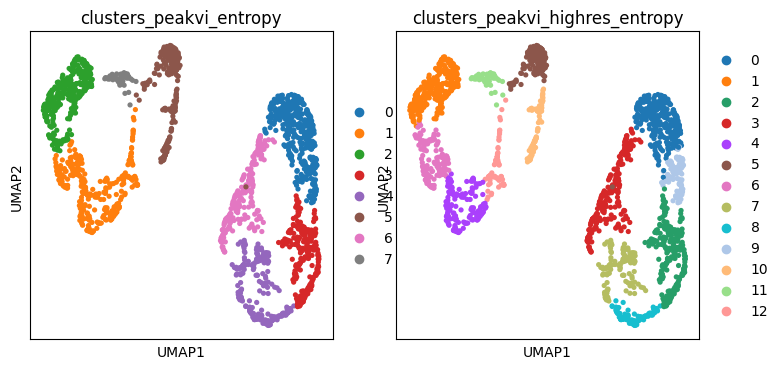

In [ ]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(entropy_peak, color=['clusters_peakvi_entropy', 'clusters_peakvi_highres_entropy'], wspace=0.1)

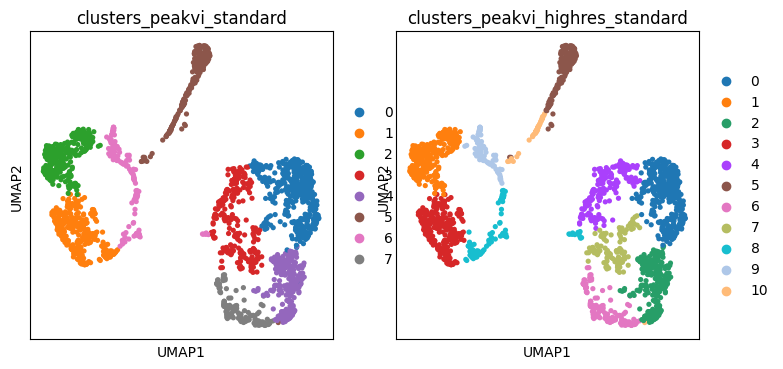

In [ ]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(peak, color=[ 'clusters_peakvi_standard', 'clusters_peakvi_highres_standard'], wspace=0.1)

## Matching atac bc with RNA bc

In [3]:
bc_map = bc_map_pd.set_index('atac_barcodes')

entropy_peak.obs['atac_bc'] =  entropy_peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
entropy_peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in entropy_peak.obs.columns:
    entropy_peak.obs = entropy_peak.obs.join(bc_map, how='inner')


peak.obs['atac_bc'] =  peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in peak.obs.columns:
    peak.obs = peak.obs.join(bc_map, how='inner')


bc_passed_entropy_df = entropy_peak.obs[['rna_barcodes']]

# RNA clustering

In [4]:
# prepare for rna-bc correspondence to atac entropy filtered barcodes
entropy_passed_bc_map=bc_passed_entropy_df.reset_index(inplace=False)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)
entropy_passed_bc_map.columns = ['atac_bc']


h5_rna_ = h5.transpose()
h5_rna_.obs['rna_barcodes'] = h5_rna_.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_rna_.obs.set_index('rna_barcodes', inplace=True)


# select gene expression only, and only the barcodes that passed entropy filtering
h5_rna_ = h5_rna_[:, h5_rna_.var['feature_type'] == 'Gene Expression']
h5_rna_ = h5_rna_[h5_rna_.obs.index.isin(entropy_passed_bc_map.index), :]
h5_rna_.obs = h5_rna_.obs.join(entropy_passed_bc_map, how='inner')

# calculate total RNA QC metrics
h5_rna_.obs['total_RNA_UMI'] = h5_rna_.X.sum(axis=1)
h5_rna_.obs['total_RNA_UMI_log'] = np.log1p(h5_rna_.obs['total_RNA_UMI'])
h5_rna_.obs['n_genes_by_RNA_counts'] = (h5_rna_.X > 0).sum(axis=1)
h5_rna_.obs['N_MT_counts'] = h5_rna_.X[:, h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].sum(axis=1)
h5_rna_.obs['MT%'] = h5_rna_.obs['N_MT_counts'] / h5_rna_.obs['total_RNA_UMI'] * 100

X_10k = sc.pp.normalize_total(h5_rna_, target_sum=1e4, inplace=False)['X']
h5_rna_.layers['log1p_counts'] = np.log1p(X_10k.copy())

h5_rna = h5_rna_[:, ~h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].copy() # Remove MT genes

# Add gene_name column 
h5_rna.var['gene_name'] = h5_rna.var['name'].astype(str)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [5]:
h5_rna, h5_rna_.shape

(AnnData object with n_obs × n_vars = 2125 × 36588
     obs: 'barcodes', 'atac_bc', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end', 'gene_name'
     layers: 'log1p_counts',
 (2125, 36601))

In [6]:
sc.pp.filter_genes(h5_rna, min_counts=3)
h5_rna.raw = h5_rna # keep full dimension safe
h5_rna.layers['counts'] = h5_rna.X
sc.pp.highly_variable_genes(
h5_rna,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [7]:
scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(h5_rna, layer="counts")
vae = scvi.model.SCVI(h5_rna, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()
h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()


sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
sc.tl.umap(h5_rna, min_dist=0.3)

# print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
# vae_model_folder=os.path.join(args.o[0], "integrated_scvi_model")
# vae.save(vae_model_folder)

Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/_scvi.py:168: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/gener

RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# clustering using scVI latent representation via Leiden
sc.tl.leiden(h5_rna, key_added="leiden_RNA_scVI", resolution=atac_resolution + 0.1)

In [8]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'MT%'], wspace=0.2, size=30, ncols=2)

KeyError: "Could not find 'umap' or 'X_umap' in .obsm"

## Cell-type annotation from Julianaa

### Provicve clsuter to cell-type map

In [101]:
# Juliana's cell type annotation
RNAcluster_celltype_map = {
'0': 'CD14+ Mo',
'1': 'CD4+CD8+naiveTCells',
'2': 'Tregs',
'3': 'Bcells',
'4': 'ILC/NK Cells',
'5': 'MAIT/NKT Cells',
'6': 'gammaSignma Tcells',
'7': 'Garbage',
'8': 'CD16+ Mo',
'9': 'pDC',
'10': 'Plasma cells (noisy)'
}

In [102]:
h5_rna.obs['celltype'] = h5_rna.obs['leiden_RNA_scVI'].map(RNAcluster_celltype_map)

### plot to see cell-type fraction of reads in peaks (FRIP) for standard peak set and entropy peak set

In [119]:
if 'standard_peak_FRIP' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['standard_peak_FRIP'], inplace=True)
if 'entropy_peak_FRIP' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['entropy_peak_FRIP'], inplace=True)
    
h5_rna.obs = h5_rna.obs.merge(standard_peak_frip[['frag_overlap_peaks%']].rename(columns={'frag_overlap_peaks%': 'standard_peak_FRIP'}),\
    left_on='atac_bc', right_index=True, how='left')

h5_rna.obs = h5_rna.obs.merge(entropy_peak_frip[['frag_overlap_entropy_peaks%']].rename(columns={'frag_overlap_entropy_peaks%': 'entropy_peak_FRIP'}),\
    left_on='atac_bc', right_index=True, how='left')

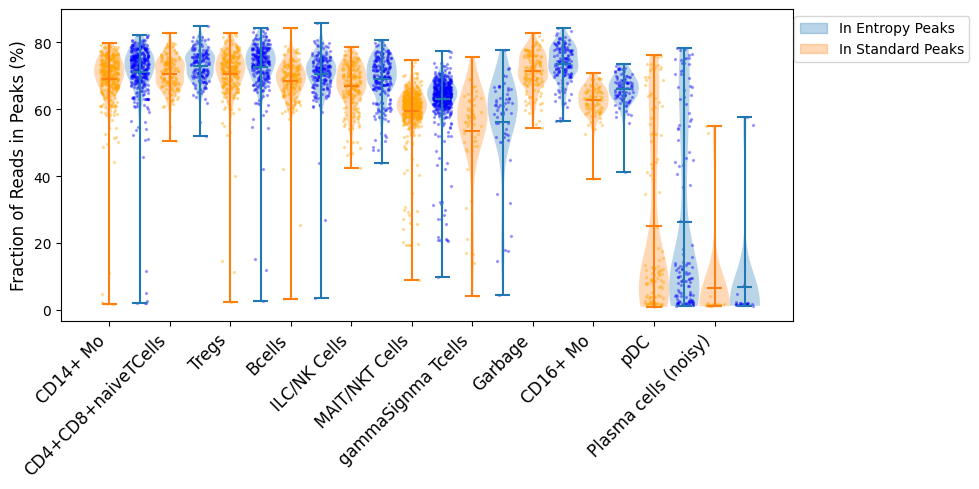

In [124]:
# color_maps = {'0': 'blue', '1': 'orange', '2': 'green', '3': 'red', '4': 'purple',
#               '5': 'brown', '6': 'pink', '7': 'gray', '8': 'olive', '9': 'cyan', '10': 'magenta'}
x_positions = range(11)
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(10, 5))

# Violin plots
standard_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == c, 'standard_peak_FRIP'] for c in h5_rna.obs['leiden_RNA_scVI'].unique()]
entropy_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == c, 'entropy_peak_FRIP'] for c in h5_rna.obs['leiden_RNA_scVI'].unique()]

add_label(ax.violinplot( entropy_peak_data, 
              positions=[x + widths for x in x_positions], widths=widths, vert=True, 
              showmeans=True,), 'In Entropy Peaks')
add_label(ax.violinplot( standard_peak_data, 
              positions=x_positions, widths=widths, vert=True, 
              showmeans=True), 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.15, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size

for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i], color='orange')
for i, group_data in enumerate(entropy_peak_data):
    add_jittered_points(ax, group_data, [x + widths for x in x_positions][i], color='blue')



ax.set_xticks(x_positions)
ax.set_xticklabels([RNAcluster_celltype_map[str(c)] for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
plt.legend(*zip(*labels), loc='upper right', bbox_to_anchor=(1.25, 1), ncol=1)

plt.tight_layout()


In [126]:
1888/ (1888 + 71)

0.9637570188871873

# Compare Cell-calling approaches

## Load RNA cell Barcodes from RNA-only modality CR analysis

In [ ]:
# Load Cell Ranger  RNA filtering criteria barcodes
CR_rnamodality_BC_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/rna/VIB_10xmultiome_2_rna/outs/filtered_feature_bc_matrix/barcodes.tsv'
CR_rnamodality_bc = pd.read_csv(CR_rnamodality_BC_file, header=None, sep='\t', names=['barcodes'])

# Load Cell Ranger ATAC filtering criteria barcodes
CR_atacmodality_BC_file ='/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/filtered_peak_bc_matrix/barcodes.tsv'
CR_atacmodality_bc = pd.read_csv(CR_atacmodality_BC_file, header=None, sep='\t', names=['barcodes'])

CR_rnamodality_bc['rna_bc'] = CR_rnamodality_bc['barcodes'].map(lambda x: x.split('-1')[0])
CR_atacmodality_bc['atac_bc'] = CR_atacmodality_bc['barcodes'].map(lambda x: x.split('-1')[0])


# Load Entropy value for each barcode on atac 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_df_file = os.path.join(entropy_dir, 'chr1_barcode_entropy_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])
entropy_df['atac_bc'] = entropy_df.index.map(lambda x: x.split('-1')[0])

# Load Entropy filtered atac barcodes
# Use entropy_peak.obs or peak.obs # TODO: Change to be entropy_passed barcodes file 

# Load  atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')

# Summary statistics about Fraction of Reads in Peaks (FRIP)
standard_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_peaks.csv')
entropy_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_entropypeaks.csv')


standard_peak_frip = pd.read_csv(standard_peak_frip_file, index_col=None, sep='\t')
entropy_peak_frip = pd.read_csv(entropy_peak_frip_file, index_col=None, sep='\t')
standard_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip['atac_bc'] = entropy_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip['atac_bc'] = standard_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip.set_index('atac_bc', inplace=True)
entropy_peak_frip.set_index('atac_bc', inplace=True)


# Load peak annotations [including peak AUC score from Genrich peaks]
annotation_dir = os.path.join(entropy_dir, 'annotation')
peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_peaks.bed'),      sep='\t')
entropy_peak_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_entropy_peaks.bed'), sep='\t')
lost_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_lost_peaks.bed'), sep='\t')
newly_discovered_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_newly_discovered_peaks.bed'),  sep='\t')

((33287, 8),)

In [136]:
if 'standard_peak_FRIP' in entropy_df.columns:
    entropy_df.drop(columns=['standard_peak_FRIP'], inplace=True)
if 'entropy_peak_FRIP' in entropy_df.columns:
    entropy_df.drop(columns=['entropy_peak_FRIP'], inplace=True)
    
entropy_df = entropy_df.merge(standard_peak_frip[['frag_overlap_peaks%']].rename(columns={'frag_overlap_peaks%': 'standard_peak_FRIP'}),\
    left_on='atac_bc', right_index=True, how='left')
entropy_df = entropy_df.merge(entropy_peak_frip[['frag_overlap_entropy_peaks%']].rename(columns={'frag_overlap_entropy_peaks%': 'entropy_peak_FRIP'}),\
    left_on='atac_bc', right_index=True, how='left')

## Map RNA and ATAC barcodes

In [138]:
bc_map = bc_map_pd.set_index('atac_barcodes')

if entropy_df.index.name != 'atac_barcodes':
    entropy_df.set_index('atac_bc', inplace=True)
    entropy_df.index.name = 'atac_barcodes'
    entropy_df['atac_bc'] = entropy_df.index.values
    
if 'rna_barcodes' not in entropy_df.columns:
    entropy_df = entropy_df.join(bc_map, how='inner')
    

entropy_df.shape

(33287, 11)

In [143]:
entropy_df.head()

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,log10_Entropy,standard_peak_FRIP,entropy_peak_FRIP,atac_bc,rna_barcodes,rna_pass_CR,atac_pass_CR,atac_pass_entropy,identified_by_atac
atac_barcodes,,,,,,,,,,,,,,,
AAGCCATAGCTAATAG,0.005725,1.069145,11,0.343957,0.708959,0.999545,-2.242193,3.930818,4.559748,AAGCCATAGCTAATAG,TCCGCCATCCAAGTTA,False,False,False,none
CACGGTAAGAATCACA,0.004039,1.910865,19,1.377521,0.252203,0.999694,-2.393755,3.393214,3.992016,CACGGTAAGAATCACA,AGTTATGTCTTGGACG,False,False,False,none
ACTGGCTTCTAACTGT,0.013996,2.526995,94,2.283363,0.101941,0.998739,-1.853984,5.901288,6.330472,ACTGGCTTCTAACTGT,TCACCTCAGCACCACA,False,False,False,none
TCAGGCTTCTTTGGTG,0.004926,1.123864,10,0.376438,0.686302,0.999616,-2.307501,4.285714,4.285714,TCAGGCTTCTTTGGTG,CGCTATGAGTCAATTG,False,False,False,none
GGTTTACGTCACAGGG,0.007795,2.188419,43,1.624756,0.196960,0.999355,-2.108172,3.285421,3.285421,GGTTTACGTCACAGGG,TGTGGCTCATGAGTTT,False,False,False,none


In [178]:
entropy_df['atac_pass_CR'].sum() - 1888

58

## Plot results

In [140]:
entropy_df['rna_pass_CR'] = entropy_df['rna_barcodes'].isin(CR_rnamodality_bc['rna_bc'])
entropy_df['atac_pass_CR'] = entropy_df['atac_bc'].isin(CR_atacmodality_bc['atac_bc'])
entropy_df['atac_pass_entropy'] = entropy_df['atac_bc'].isin(entropy_peak.obs.index)

In [141]:
entropy_df['identified_by_atac'] = entropy_df.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_CR'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] else 'none')), axis=1
)

----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [64.83361841785602, 49.474955830539315, 50.6086314955297, 5.420781219583986]
median 	 [67.05558858501783, 63.065230335425326, 56.78960603520537, 4.362416107382551]


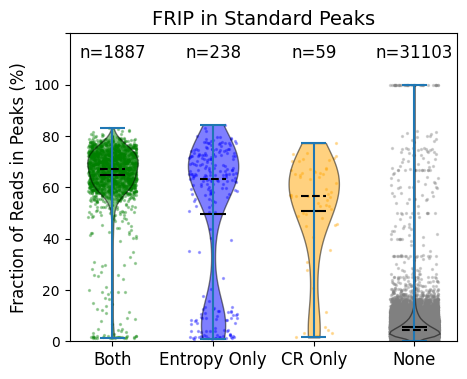

In [193]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors = ['green', 'blue', 'orange', 'gray']
entropy_vales = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'standard_peak_FRIP'] for cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in entropy_vales]

mean_entropy_values = [np.mean(a) for a in entropy_vales]
median_entropy_values = [np.median(a) for a in entropy_vales]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(entropy_vales):
    add_jittered_points(ax, group_data, x_positions[i], color=colors[i])


v1 = ax.violinplot( entropy_vales, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

ax.set_title('FRIP in Standard Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')

----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [67.30619038747956, 51.41261077847256, 52.11442739696759, 5.77335584249837]
median 	 [69.62162162162161, 66.03347714924897, 58.51318944844125, 4.69208211143695]


Text(0.5, 1.0, 'FRIP in Entropy Peaks')

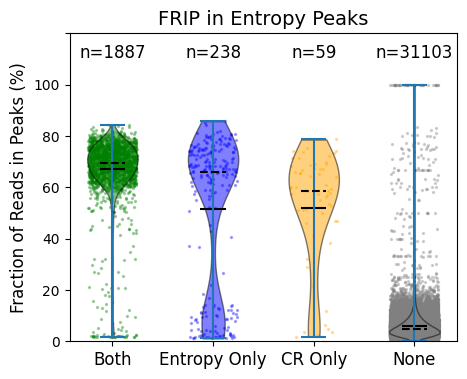

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors = ['green', 'blue', 'orange', 'gray']
entropy_vales = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'entropy_peak_FRIP'] for cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in entropy_vales]

mean_entropy_values = [np.mean(a) for a in entropy_vales]
median_entropy_values = [np.median(a) for a in entropy_vales]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(entropy_vales):
    add_jittered_points(ax, group_data, x_positions[i], color=colors[i])


v1 = ax.violinplot( entropy_vales, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

ax.set_title('FRIP in Entropy Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')



----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [2.47257196962355, 1.937654947933248, 1.5057959014378905, 0.3525746229143849]
median 	 [2.3693647540983562, 2.0777027027027017, 1.4025245441795278, 0.20491803278688536]


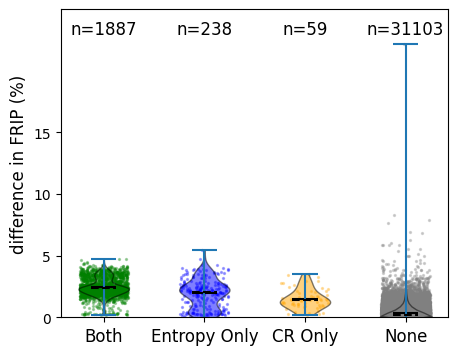

In [199]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors = ['green', 'blue', 'orange', 'gray']
entropy_vales = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'entropy_peak_FRIP'] - \
    entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'standard_peak_FRIP'] for \
        cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in entropy_vales]

mean_entropy_values = [np.mean(a) for a in entropy_vales]
median_entropy_values = [np.median(a) for a in entropy_vales]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(entropy_vales):
    add_jittered_points(ax, group_data, x_positions[i], color=colors[i])


v1 = ax.violinplot( entropy_vales, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('difference in FRIP (%)', fontsize=12)
ax.set_ylim(0, 25)
ax.set_yticks(range(0, 20, 5))


for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)
    
print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')


In [108]:
if 'identified_by_atac' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(entropy_df[['rna_barcodes', 'identified_by_atac', 'rna_pass_CR']],  left_index=True, right_on='rna_barcodes', how='left')

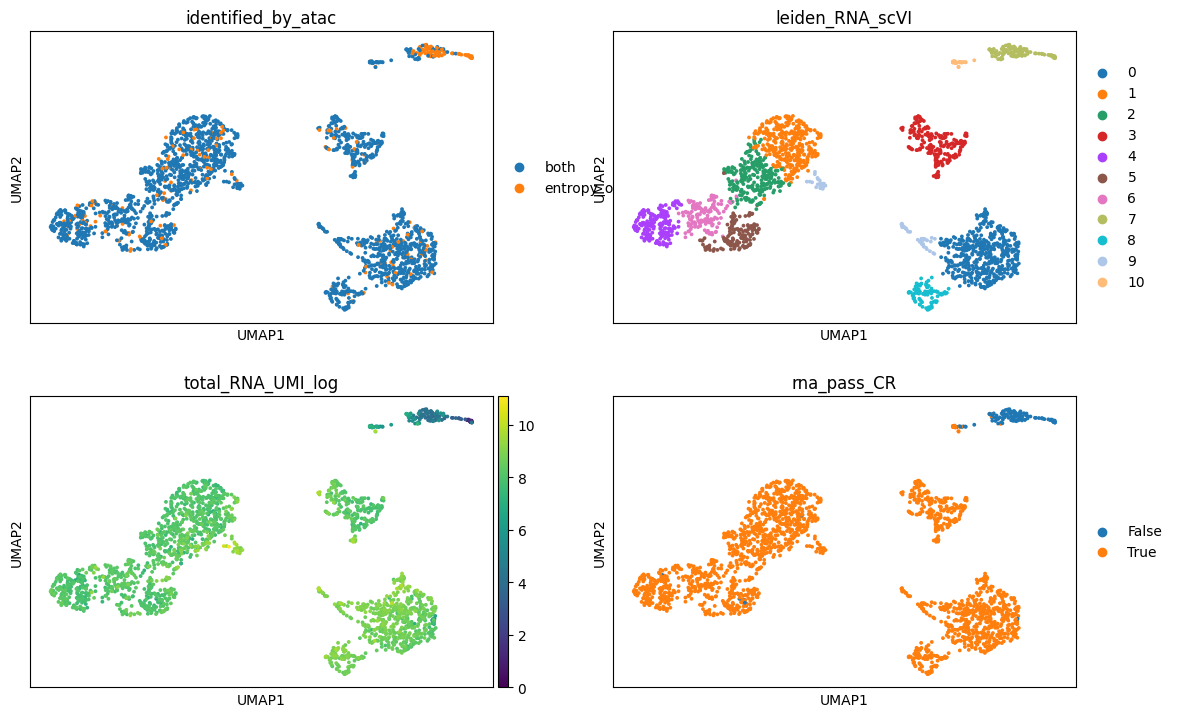

In [110]:
with plt.rc_context({'figure.figsize': (6, 4)}):
    sc.pl.umap(h5_rna, color=['identified_by_atac', 'leiden_RNA_scVI', 'total_RNA_UMI_log', 'rna_pass_CR'], size=30, ncols=2)

In [111]:
h5_rna.obs.groupby('identified_by_atac').size()

/tmp/ipykernel_824487/2428117809.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby('identified_by_atac').size()


identified_by_atac
both            1887
entropy_only     238
dtype: int64

In [112]:
h5_rna.obs.groupby(['leiden_RNA_scVI', 'identified_by_atac']).size().fillna(0).unstack()

/tmp/ipykernel_824487/2944061862.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby(['leiden_RNA_scVI', 'identified_by_atac']).size().fillna(0).unstack()


identified_by_atac,both,entropy_only
leiden_RNA_scVI,,
0,443,39
1,337,27
2,240,19
3,201,19
4,179,17
5,145,13
6,132,10
7,43,82
8,91,6


In [92]:
82 / 238

0.3445378151260504

<Axes: xlabel='leiden_RNA_scVI', ylabel='count'>

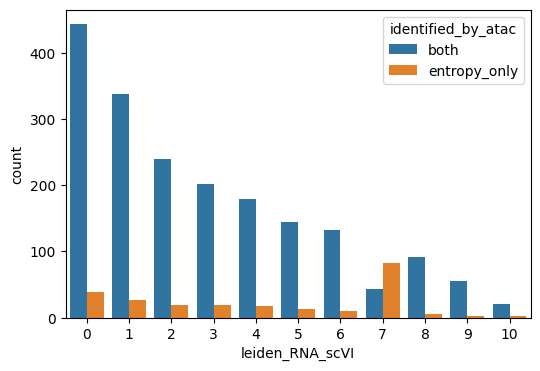

In [86]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=h5_rna.obs, x='leiden_RNA_scVI', hue='identified_by_atac', ax=ax)

## Peak AUC score 

In [ ]:
# Load peak annotations [including peak AUC score from Genrich peaks]
annotation_dir = os.path.join(entropy_dir, 'annotation')
peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_peaks.bed'),      sep='\t')
entropy_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_entropy_peaks.bed'), sep='\t')
lost_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_lost_peaks.bed'), sep='\t')


## calcualte peak size
newly_discovered_peaks_annot['peak_size'] = newly_discovered_peaks_annot['End'] - newly_discovered_peaks_annot['Start']
lost_peaks_annot['peak_size'] = lost_peaks_annot['End'] - lost_peaks_annot['Start']

peaks_annot['peak_size'] = peaks_annot['End'] - peaks_annot['Start']
entropy_peaks_annot['peak_size'] = entropy_peaks_annot['End'] - entropy_peaks_annot['Start']

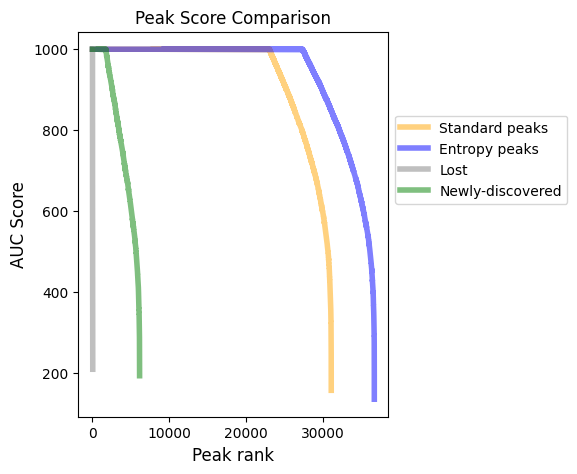

In [214]:
fig, ax = plt.subplots(figsize=(4, 5))
ax.plot(peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='orange', alpha=0.5, label='Standard peaks', lw=4)
ax.plot(entropy_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='blue', alpha=0.5, label='Entropy peaks', lw=4)
ax.plot(lost_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='gray', alpha=0.5, label='Lost', lw=4)
ax.plot(newly_discovered_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='green', alpha=0.5, label='Newly-discovered', lw=4)
ax.set_title('Peak Score Comparison', fontsize=12)
ax.set_xlabel('Peak rank', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.legend( loc='upper right', bbox_to_anchor=(1.6, .8))

--- 	 Standard Peaks , Entropy Peaks , Lost Peaks , Newly-discovered Peaks
Mean [943.8465419719759, 943.6453483623295, 544.0571428571428, 806.1140250855188]
Median [1000.0, 1000.0, 509.0, 845.0]


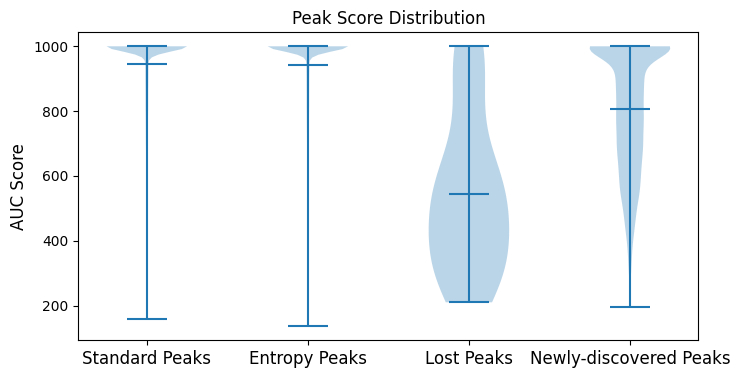

In [233]:
fig, ax = plt.subplots(figsize=(8, 4))
x_positions = range(4)
width = 0.5 

auc_score = [
             peaks_annot['Peak Score'], entropy_peaks_annot['Peak Score'], 
             lost_peaks_annot['Peak Score'], newly_discovered_peaks_annot['Peak Score'], 
             ]
mean_score = [np.mean(a) for a in auc_score]
median_score = [np.median(a) for a in auc_score]

ax.violinplot(auc_score, widths=width, positions=x_positions, showmeans=True,  vert=True)

ax.set_xticks(x_positions, [ 'Standard Peaks', 'Entropy Peaks', 'Lost Peaks', 'Newly-discovered Peaks'], fontsize=12)  
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title('Peak Score Distribution', fontsize=12)

print ('--- \t Standard Peaks , Entropy Peaks , Lost Peaks , Newly-discovered Peaks')
print (f'Mean {mean_score}')
print (f'Median {median_score}')

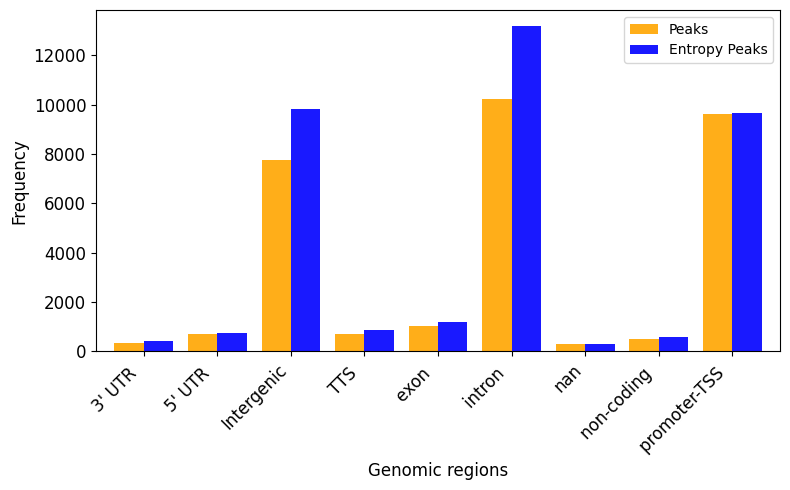

In [241]:
def simplify_annotation(annot_df, inplace=False):
    """
    Simplify the Annotation column.
    """
    if not inplace:
        annot_df = annot_df.copy()
        annot_df['simple_annotation'] = annot_df['Annotation'].apply(lambda x: str(x).split('(')[0])  
        return annot_df
    else:
        # in place change of the  DataFrame
        annot_df['simple_annotation'] = annot_df['Annotation'].apply(lambda x: str(x).split('(')[0])  
        
simplify_annotation(peaks_annot, inplace=True)
simplify_annotation(entropy_peaks_annot, inplace=True)
simplify_annotation(lost_peaks_annot, inplace=True)
simplify_annotation(newly_discovered_peaks_annot, inplace=True)

        
peaks_freq = peaks_annot['simple_annotation'].value_counts()
entropy_peaks_freq = entropy_peaks_annot['simple_annotation'].value_counts()
newly_discovered_peaks_freq = newly_discovered_peaks_annot['simple_annotation'].value_counts()
lost_peaks_freq = lost_peaks_annot['simple_annotation'].value_counts()

freq_df = pd.DataFrame({
    'Peaks': peaks_freq,
    'Entropy Peaks': entropy_peaks_freq
}).fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
freq_df.plot(kind='bar', width=0.8, alpha=0.9, ax=ax, color=['orange', 'blue'], fontsize=12)
# ax.set_title('Peak Annotation Frequency Comparison', fontsize=12)
ax.set_xlabel('Genomic regions', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
fig.tight_layout()

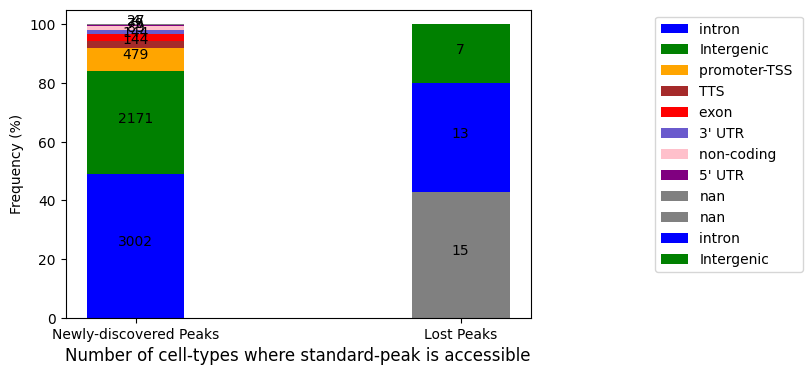

In [ ]:
color_map = {'intron ': 'blue', 'promoter-TSS ': 'orange', 'Intergenic': 'green', 'exon ': 'red',
                "5' UTR ": 'purple', 'TTS ': 'brown', 'non-coding ': 'pink', "3' UTR ": 'slateblue', 'nan': 'grey'}
index_map = {'intron ': 0, 'promoter-TSS ': 1, 'Intergenic': 2, 'exon ': 3,
                "5' UTR ": 4, 'TTS ': 5, 'non-coding ': 6, "3' UTR ": 7, 'nan': 8}

width = 0.3  # the width of the bars
fig, ax = plt.subplots(   figsize=(6,4))

x = [0] 
bottom =np.array([.0])
for genome_type  in newly_discovered_peaks_freq.index.values:

    y_perc =np.array([newly_discovered_peaks_freq[genome_type]])  / newly_discovered_peaks_freq.sum() * 100
    rects = ax.bar( x, y_perc,  width, label=genome_type, color=color_map[genome_type], bottom=bottom)
    bottom += y_perc

    value_labels = [newly_discovered_peaks_freq[genome_type]]
    value_pos = 'center'
    ax.bar_label(rects, labels=value_labels , padding=3, fontsize=10, label_type=value_pos) 




x = [1]
bottom =np.array([.0])
for genome_type  in lost_peaks_freq.index.values:
    
    y_perc =np.array([lost_peaks_freq[genome_type]]) / lost_peaks_freq.sum() * 100
    rects = ax.bar( x, y_perc,  width, label=genome_type, color=color_map[genome_type], bottom=bottom)
    bottom += y_perc

    value_labels = [lost_peaks_freq[genome_type]]
    value_pos = 'center'
    ax.bar_label(rects, labels=value_labels , padding=3, fontsize=10, label_type=value_pos)
    
    
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Frequency (%)')
ax.set_xlabel('Number of cell-types where standard-peak is accessible', fontsize=12) 
ax.set_xticks([0, 1], ['Newly-discovered Peaks', 'Lost Peaks'])
ax.legend(loc='upper right', ncols=1, bbox_to_anchor=(1.6, 1))



plt.show()

In [380]:
lost_peaks_freq ,  newly_discovered_peaks_freq, 



(simple_annotation
 nan           15
 intron        13
 Intergenic     7
 Name: count, dtype: int64,
 simple_annotation
 intron           3002
 Intergenic       2171
 promoter-TSS      479
 TTS               144
 exon              144
 3' UTR             89
 non-coding         79
 5' UTR             27
 nan                 4
 Name: count, dtype: int64)

In [382]:
lost_peaks_freq / lost_peaks_freq.sum(), newly_discovered_peaks_freq / newly_discovered_peaks_freq.sum()

(simple_annotation
 nan           0.428571
 intron        0.371429
 Intergenic    0.200000
 Name: count, dtype: float64,
 simple_annotation
 intron           0.489005
 Intergenic       0.353641
 promoter-TSS     0.078026
 TTS              0.023457
 exon             0.023457
 3' UTR           0.014497
 non-coding       0.012869
 5' UTR           0.004398
 nan              0.000652
 Name: count, dtype: float64)

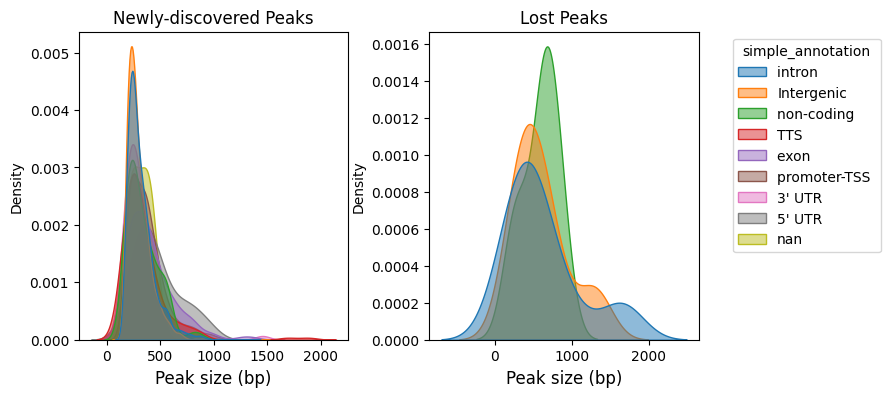

In [311]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

sns.kdeplot(data=newly_discovered_peaks_annot, x='peak_size', hue='simple_annotation', fill=True, ax=ax[0], 
            common_norm=False, alpha=0.5, color=color_map)
sns.kdeplot(data=lost_peaks_annot, x='peak_size', hue='simple_annotation', fill=True, ax=ax[1], 
            common_norm=False, alpha=0.5, color=color_map)

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Lost Peaks', fontsize=12)


ax[1].legend_.remove()
sns.move_legend(ax[0], "upper right", bbox_to_anchor=(3, 1))

fig.subplots_adjust(wspace=0.3)

In [ ]:

    
fig, ax = plt.subplots( figsize=(10, 5))

# Violin plots
standard_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == c, 'standard_peak_FRIP'] for c in h5_rna.obs['leiden_RNA_scVI'].unique()]
entropy_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == c, 'entropy_peak_FRIP'] for c in h5_rna.obs['leiden_RNA_scVI'].unique()]

add_label(ax.violinplot( entropy_peak_data, 
              positions=[x + widths for x in x_positions], widths=widths, vert=True, 
              showmeans=True,), 'In Entropy Peaks')
add_label(ax.violinplot( standard_peak_data, 
              positions=x_positions, widths=widths, vert=True, 
              showmeans=True), 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.15, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size

for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i], color='orange')
for i, group_data in enumerate(entropy_peak_data):
    add_jittered_points(ax, group_data, [x + widths for x in x_positions][i], color='blue')

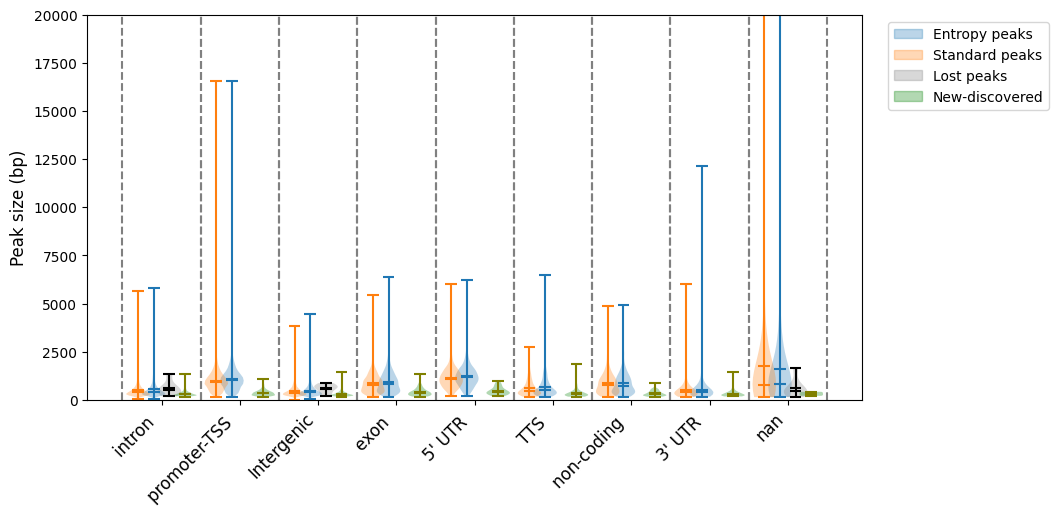

In [372]:
position_map = {'intron ': 0, 'promoter-TSS ': 1, 'Intergenic': 2, 'exon ': 3,
                "5' UTR ": 4, 'TTS ': 5, 'non-coding ': 6, "3' UTR ": 7, 'nan': 8}

position_map_reversed = {v: k for k, v in position_map.items()}


def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    

x_positions = range(len(position_map)) 
width = 0.3  # the width of the bars
labels = []

fig, ax = plt.subplots( figsize=(10, 5))

standard_type = peaks_annot['simple_annotation'].unique()
entropy_type = entropy_peaks_annot['simple_annotation'].unique()
newly_discovered_type = newly_discovered_peaks_annot['simple_annotation'].unique()
lost_type = lost_peaks_annot['simple_annotation'].unique()

standard_peak_size = [ peaks_annot.loc[peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in standard_type ]

entropy_peak_size = [ entropy_peaks_annot.loc[entropy_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in entropy_type ]
newly_discovered_peak_size = [ newly_discovered_peaks_annot.loc[newly_discovered_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in newly_discovered_type     ]  
lost_peak_size = [ lost_peaks_annot.loc[lost_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in lost_type ]


v2 =ax.violinplot( entropy_peak_size, 
              positions=[position_map[genome_type] - 0.1 for genome_type in entropy_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
add_label(v2, 'Entropy peaks')

v1 = ax.violinplot( standard_peak_size, 
              positions=[position_map[genome_type] - 0.3 for genome_type in standard_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
add_label(v1, 'Standard peaks')


v3 = ax.violinplot( lost_peak_size, 
              positions=[position_map[genome_type] + 0.1 for genome_type in lost_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
# change color 
for body in v3['bodies']:
    body.set_facecolor( 'grey'   )
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    v3[partname].set_edgecolor('black')
add_label(v3, 'Lost peaks')


v4 =ax.violinplot( newly_discovered_peak_size, 
              positions=[position_map[genome_type] + 0.3 for genome_type in newly_discovered_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
# change color
for body in v4['bodies']:
    body.set_facecolor('green')
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    v4[partname].set_edgecolor('olive')

add_label(v4, 'New-discovered')


## Add vertical line to separate each group
for x in x_positions:
    ax.vlines(x + 0.5 , ymin=0, ymax=20000, colors='grey', linestyles='--')
    ax.vlines(x - 0.5 , ymin=0, ymax=20000, colors='grey', linestyles='--')


ax.set_xticks(x_positions)
ax.set_xticklabels([position_map_reversed[i] for i in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylim(0, 20000)
ax.set_ylabel('Peak size (bp)', fontsize=12)
plt.legend(*zip(*labels), loc='upper right', bbox_to_anchor=(1.25, 1), ncol=1)

# Check cCRE annotations

In [394]:
cCRE_subdir=os.path.join(entropy_dir, 'cCRE_annotation')
cCRE_newly_discovered_peaks_file = os.path.join(cCRE_subdir, 'cCRE_annot_newly_discovered_peaks.bed')
cCRE_lost_peaks_file = os.path.join(cCRE_subdir, 'cCRE_annot_lost_peaks.bed')

cCRE_newly_discovered_peaks = pd.read_csv(cCRE_newly_discovered_peaks_file, sep='\t', header=None)
cCRE_lost_peaks = pd.read_csv(cCRE_lost_peaks_file, sep='\t', header=None)

columns = ['chrom', 'chromStart', 'chromEnd', 'name', 'peak_auc_score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak', 
           'cCREs_chrom', 'cCREs_start', 'cCREs_end', 'cCREs_an1', 'cCREs_an2', 'encode_label', 'overlap_bp']

cCRE_lost_peaks.columns = columns
cCRE_newly_discovered_peaks.columns = columns

cCRE_lost_peaks.shape, cCRE_newly_discovered_peaks.shape,

((35, 17), (7834, 17))

In [399]:
cCRE_newly_discovered_peaks.head()

,chrom,chromStart,chromEnd,name,peak_auc_score,strand,signalValue,pValue,qValue,peak,cCREs_chrom,cCREs_start,cCREs_end,cCREs_an1,cCREs_an2,encode_label,overlap_bp
0,chr1,976091,976507,peak_37,718,.,298.735504,3.889666,-1,104,chr1,975985,976335,EH38D4327848,EH38E2776741,"dELS,CTCF-bound",244
1,chr1,976091,976507,peak_37,718,.,298.735504,3.889666,-1,104,chr1,976424,976654,EH38D4327849,EH38E2776742,"dELS,CTCF-bound",83
2,chr1,1079635,1080360,peak_48,378,.,273.890259,2.925810,-1,400,chr1,1079459,1079809,EH38D4328076,EH38E2776927,"dELS,CTCF-bound",174
3,chr1,1079635,1080360,peak_48,378,.,273.890259,2.925810,-1,400,chr1,1079868,1080027,EH38D2115702,EH38E1310453,"dELS,CTCF-bound",159
4,chr1,1079635,1080360,peak_48,378,.,273.890259,2.925810,-1,400,chr1,1080115,1080463,EH38D4328077,EH38E2776928,"dELS,CTCF-bound",245


In [392]:
cCRE_lost_peaks.head(10)

,chrom,chromStart,chromEnd,name,peak_auc_score,strand,signalValue,pValue,qValue,peak,cCREs_chrom,cCREs_start,cCREs_end,cCREs_an1,cCREs_an2,encode_label,overlap_bp
0,chr1,2663175,2663930,peak_134,342,.,257.992554,3.048749,-1,63,.,-1,-1,.,.,.,0
1,chr1,2664230,2665587,peak_135,371,.,503.672852,2.914509,-1,679,.,-1,-1,.,.,.,0
2,chr1,2671720,2672357,peak_136,436,.,277.447876,3.144313,-1,144,.,-1,-1,.,.,.,0
3,chr1,2748299,2748725,peak_138,501,.,213.434113,3.235945,-1,181,.,-1,-1,.,.,.,0
4,chr1,2756527,2757065,peak_139,509,.,273.738647,3.205816,-1,66,.,-1,-1,.,.,.,0
5,chr1,3501972,3502147,peak_143,1000,.,226.675674,3.767873,-1,85,chr1,3502064,3502405,EH38D4332663,EH38E2780238,dELS,83
6,chr1,16670242,16670866,peak_399,370,.,231.137512,2.982659,-1,296,.,-1,-1,.,.,.,0
7,chr1,16749721,16750351,peak_405,427,.,268.858154,3.235945,-1,423,.,-1,-1,.,.,.,0
8,chr1,144102142,144103010,peak_1824,240,.,208.247543,3.048749,-1,483,.,-1,-1,.,.,.,0
9,chr1,144843659,144844879,peak_1847,256,.,312.655212,2.879614,-1,809,.,-1,-1,.,.,.,0


In [ ]:
# Total CREs lost peaks cover
cCRE_lost_peaks.loc[cCRE_lost_peaks['overlap_bp'] > 0].shape

(5, 17)

In [398]:
# total lost peaks that cover CREs 
len(cCRE_lost_peaks.loc[cCRE_lost_peaks['overlap_bp'] > 0 ]['name'].unique()) 

5

In [ ]:
# Total CREs newly-discovered peaks cover
cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0 ].shape  # total cCREs are covered 


(7697, 17)

In [ ]:
# total newly-discovered peaks that cover CREs 
len(cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0 ]['name'].unique()) 

6002